<a href="https://colab.research.google.com/github/srujalnikam/Git/blob/master/linear_experiment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

import pandas as pd

In [9]:
from sklearn.model_selection import train_test_split

#simple data
#x = np.array([2,4,6,8]).reshape((-1, 1))
#y = np.array([3,7,5,10])

df = pd.read_csv("/content/student_linear_regression_60_dataset.csv")
df.head()

X = df[['study_hours']]
y = df['student_marks']

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training X:")
print(X_train)

print("Testing X:")
print(X_test)

print("Training y:")
print(y_train)

print("Testing y:")
print(y_test)

Training X:
    study_hours
31          9.0
3           2.0
52         14.5
17          5.5
8           3.5
6           3.0
40         11.5
4           2.5
43         12.0
19          6.0
34         10.0
58         16.0
25          7.5
56         15.5
15          5.0
27          8.0
9           3.5
30          9.0
26          8.0
16          5.5
24          7.5
55         15.0
11          4.0
32          9.5
53         14.5
41         11.5
37         10.5
29          8.5
44         12.5
1           1.5
21          6.5
2           2.0
47         13.0
39         11.0
35         10.0
23          7.0
49         13.5
10          4.0
22          7.0
18          6.0
59         16.0
20          6.5
7           3.0
42         12.0
14          5.0
28          8.5
51         14.0
38         11.0
Testing X:
    study_hours
0           1.0
5           2.5
36         10.5
45         12.5
13          4.5
54         15.0
33          9.5
48         13.5
12          4.5
57         15.5
46         13.0
5

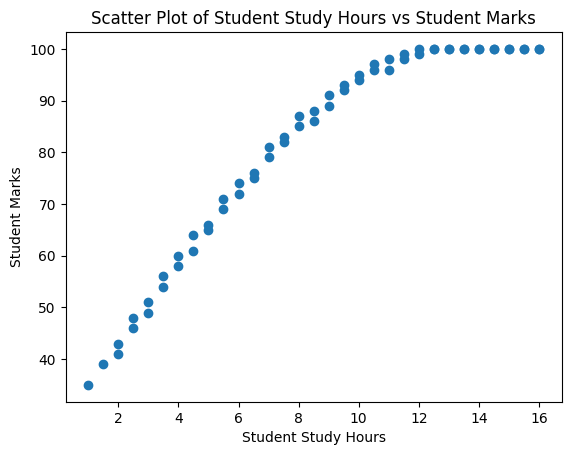

In [4]:
#print(x) print(y)
plt.scatter(x = df.study_hours, y = df.student_marks)
plt.xlabel("Student Study Hours")
plt.ylabel("Student Marks")
plt.title("Scatter Plot of Student Study Hours vs Student Marks")
plt.show()

In [6]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [7]:
lr.fit(X_train , y_train)

LinearRegression()

In [10]:
model = LinearRegression().fit(X_train, y_train)

In [12]:
r_sq = model.score(X_test, y_test)
print('coefficient of determination:', r_sq)

coefficient of determination: 0.9117066831273906


In [13]:
print('intercept:', model.intercept_)

intercept: 43.90589806731788


In [14]:
print('slope:', model.coef_)

slope: [4.35132654]


In [15]:
# prompt: print equation of line of regression

print(f"The equation of the line of regression is: y = {model.intercept_} + {model.coef_[0]}x")

The equation of the line of regression is: y = 43.90589806731788 + 4.351326542885538x


In [17]:
y_pred = model.predict(X_test)
print('predicted response:', y_pred, sep='\n')

predicted response:
[ 48.25722461  54.78421442  89.59482677  98.29747985  63.48686751
 109.17579621  85.24350022 102.6488064   63.48686751 111.35145948
 100.47314312 104.82446967]


In [19]:
y_pred = model.intercept_ + model.coef_ * X_test
print('predicted response:', y_pred, sep='\n')

predicted response:
    study_hours
0     48.257225
5     54.784214
36    89.594827
45    98.297480
13    63.486868
54   109.175796
33    85.243500
48   102.648806
12    63.486868
57   111.351459
46   100.473143
50   104.824470


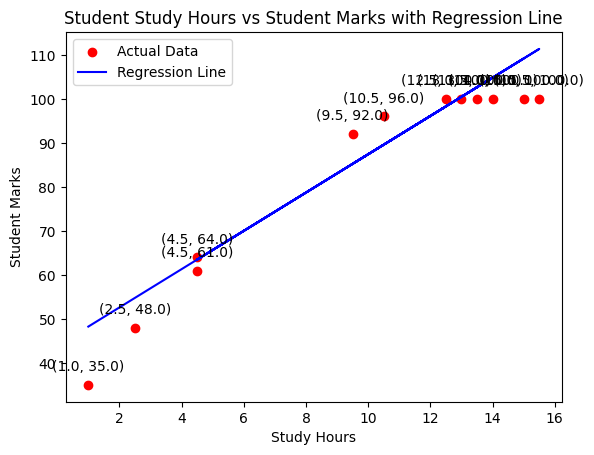

In [21]:
# Add annotations for each data point
for i in range(len(X_test)):
  plt.annotate(f"({X_test.iloc[i, 0]:.1f}, {y_test.iloc[i]:.1f})", (X_test.iloc[i, 0], y_test.iloc[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.scatter(X_test['study_hours'], y_test, color='red', label='Actual Data')
plt.plot(X_test['study_hours'], y_pred, color='blue', label='Regression Line')
plt.xlabel('Study Hours')
plt.ylabel('Student Marks')
plt.title('Student Study Hours vs Student Marks with Regression Line')
plt.legend()
plt.show()

In [24]:
x_new=9
x_new_df = pd.DataFrame([[x_new]], columns=['study_hours'])
y_new = model.predict(x_new_df)
print(y_new)

[83.06783695]


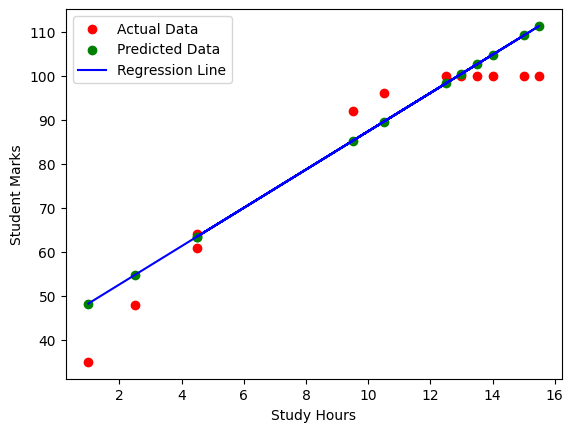

In [26]:
# prompt: plot x vs y (red dots)  and  y_pred(green dots) also show line of regression

import matplotlib.pyplot as plt

plt.scatter(X_test['study_hours'], y_test, color='red', label='Actual Data')
plt.scatter(X_test['study_hours'], y_pred, color='green', label='Predicted Data')
plt.plot(X_test['study_hours'], y_pred, color='blue', label='Regression Line')
plt.xlabel('Study Hours')
plt.ylabel('Student Marks')
plt.legend()
plt.show()

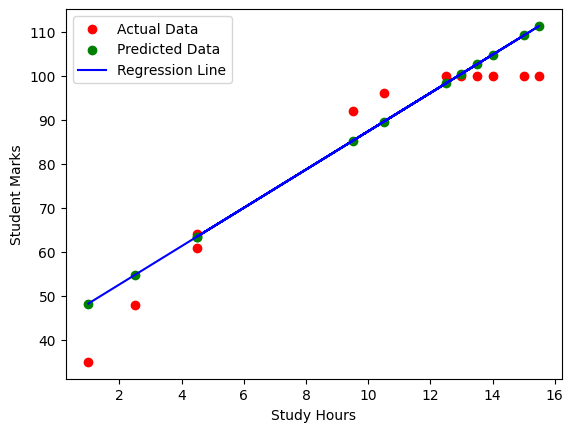

In [28]:
# prompt: plot x vs y (red dots)  and  y_pred(green dots) also show line of regression

import matplotlib.pyplot as plt

plt.scatter(X_test['study_hours'], y_test, color='red', label='Actual Data')
plt.scatter(X_test['study_hours'], y_pred, color='green', label='Predicted Data')
plt.plot(X_test['study_hours'], y_pred, color='blue', label='Regression Line')
plt.xlabel('Study Hours')
plt.ylabel('Student Marks')
plt.legend()
plt.show()

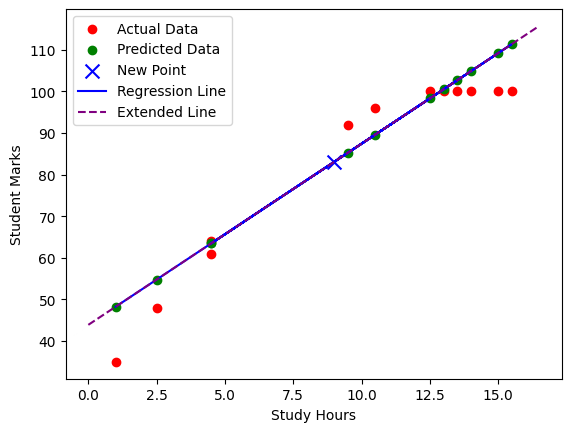

The regression line equation: y = 43.91 + 4.35x
For x = 9, the predicted y is: 83.07


In [31]:
plt.scatter(X_test['study_hours'], y_test, color='red', label='Actual Data')
plt.scatter(X_test['study_hours'], y_pred, color='green', label='Predicted Data')
plt.scatter(x_new, y_new, color='blue', marker='x', s=100, label='New Point')
plt.plot(X_test['study_hours'], y_pred, color='blue', label='Regression Line')

# Generate x values for the extended line
x_extended = np.linspace(X_test['study_hours'].min() - 1, X_test['study_hours'].max() + 1, 100)  # Adjust range as needed

# Calculate corresponding y values using the regression equation
y_extended = model.intercept_ + model.coef_[0] * x_extended

plt.plot(x_extended, y_extended, linestyle='--', color='purple', label='Extended Line')

plt.xlabel('Study Hours')
plt.ylabel('Student Marks')
plt.legend()
plt.show()

print(f"The regression line equation: y = {model.intercept_:.2f} + {model.coef_[0]:.2f}x")
print(f"For x = {x_new}, the predicted y is: {y_new[0]:.2f}")


In [32]:
x_new=5
y_new = model.predict([[x_new]])
print(y_new)

[65.66253078]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


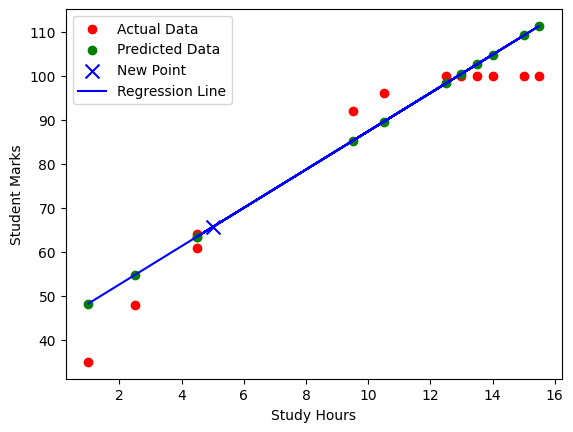

The regression line equation: y = 43.91 + 4.35x
For x = 5, the predicted y is: 65.66


In [34]:
plt.scatter(X_test['study_hours'], y_test, color='red', label='Actual Data')
plt.scatter(X_test['study_hours'], y_pred, color='green', label='Predicted Data')
plt.scatter(x_new, y_new, color='blue', marker='x', s=100, label='New Point')
plt.plot(X_test['study_hours'], y_pred, color='blue', label='Regression Line')

plt.xlabel('Study Hours')
plt.ylabel('Student Marks')
plt.legend()
plt.show()

print(f"The regression line equation: y = {model.intercept_:.2f} + {model.coef_[0]:.2f}x")
print(f"For x = {x_new}, the predicted y is: {y_new[0]:.2f}")

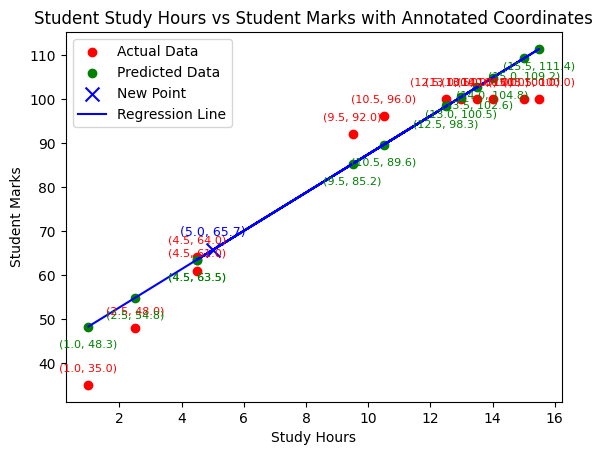

In [36]:
# prompt: show the x y ccordinate values in the above graph

# The variables X_test, y_test, y_pred, x_new, and y_new are already defined in previous cells.

plt.scatter(X_test['study_hours'], y_test, color='red', label='Actual Data')
plt.scatter(X_test['study_hours'], y_pred, color='green', label='Predicted Data')
plt.scatter(x_new, y_new, color='blue', marker='x', s=100, label='New Point')

plt.plot(X_test['study_hours'], y_pred, color='blue', label='Regression Line')

# Add annotations for each data point
# Note: Annotating all points can make the plot very crowded, consider annotating specific points if needed.
for i in range(len(X_test)):
  # Annotate actual data points
  plt.annotate(f"({X_test.iloc[i, 0]:.1f}, {y_test.iloc[i]:.1f})", (X_test.iloc[i, 0], y_test.iloc[i]),
               textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='red')
  # Annotate predicted data points
  plt.annotate(f"({X_test.iloc[i, 0]:.1f}, {y_pred.iloc[i, 0]:.1f})", (X_test.iloc[i, 0], y_pred.iloc[i, 0]),
               textcoords="offset points", xytext=(0,-15), ha='center', fontsize=8, color='green')

# Annotate the new predicted point
plt.annotate(f"({x_new:.1f}, {y_new[0]:.1f})", (x_new, y_new[0]),
             textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, color='blue')

plt.xlabel('Study Hours')
plt.ylabel('Student Marks')
plt.title('Student Study Hours vs Student Marks with Annotated Coordinates')
plt.legend()
plt.show()

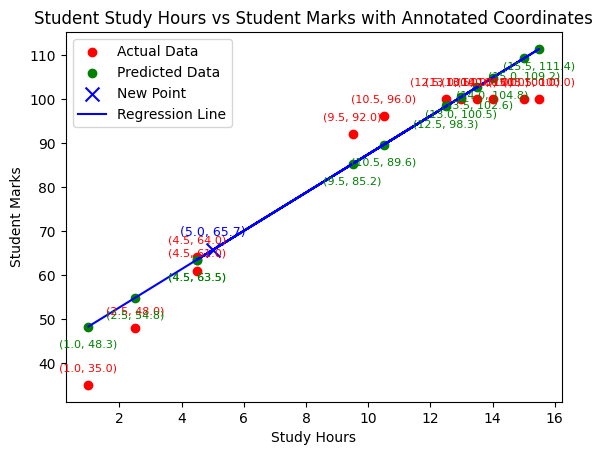

In [38]:
# The variables X_test, y_test, y_pred, x_new, and y_new are already defined in previous cells.

plt.scatter(X_test['study_hours'], y_test, color='red', label='Actual Data')
plt.scatter(X_test['study_hours'], y_pred, color='green', label='Predicted Data')
plt.scatter(x_new, y_new, color='blue', marker='x', s=100, label='New Point')

plt.plot(X_test['study_hours'], y_pred, color='blue', label='Regression Line')

# Add annotations for each data point
# Note: Annotating all points can make the plot very crowded, consider annotating specific points if needed.
for i in range(len(X_test)):
  # Annotate actual data points
  plt.annotate(f"({X_test.iloc[i, 0]:.1f}, {y_test.iloc[i]:.1f})", (X_test.iloc[i, 0], y_test.iloc[i]),
               textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='red')
  # Annotate predicted data points
  plt.annotate(f"({X_test.iloc[i, 0]:.1f}, {y_pred.iloc[i, 0]:.1f})", (X_test.iloc[i, 0], y_pred.iloc[i, 0]),
               textcoords="offset points", xytext=(0,-15), ha='center', fontsize=8, color='green')

# Annotate the new predicted point
plt.annotate(f"({x_new:.1f}, {y_new[0]:.1f})", (x_new, y_new[0]),
             textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, color='blue')

plt.xlabel('Study Hours')
plt.ylabel('Student Marks')
plt.title('Student Study Hours vs Student Marks with Annotated Coordinates')
plt.legend()
plt.show()